In [2]:
import os, sys

sys.path.insert(0, os.path.dirname(os.getcwd()))

In [1]:
import h5py
import numpy as np

import torch

import os, sys
sys.path.append(r"E:\Dai hoc\2526I\dacn\flow-matching")

from run_real_data.models import HCDFlowResMLP

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25540\140373019.py:7: SyntaxWarning: invalid escape sequence '\D'
  sys.path.append("E:\Dai hoc\2526I\dacn\flow-matching")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_25540\140373019.py:7: SyntaxWarning: invalid escape sequence '\D'
  sys.path.append("E:\Dai hoc\2526I\dacn\flow-matching")


KeyboardInterrupt: 

In [3]:
with h5py.File(r"E:\Dai hoc\2526I\dacn\flow-matching\data\holdout_hcd.hdf5") as f:
    print(f.keys())
    seqs = f["sequence_integer"][:8]
    intensities = f["intensities_raw"][:8]
    charge_oh = f["precursor_charge_onehot"][:8]
    masses_pred = f["masses_pred"][:8]
    masses_raw = f["masses_raw"][:8]
charges = np.argmax(charge_oh, axis=1) + 1

<KeysViewHDF5 ['collision_energy', 'collision_energy_aligned', 'collision_energy_aligned_normed', 'intensities_raw', 'masses_pred', 'masses_raw', 'method', 'precursor_charge_onehot', 'rawfile', 'reverse', 'scan_number', 'score', 'sequence_integer']>


In [ ]:
model_layer = 4
pep_layer = 4

min_charge, max_charge = 1, 6

model = HCDFlowResMLP(
    noise_dim=174,
    pep_dim=256,
    time_dim=128,
    charge_dim=9,
    num_blocks=model_layer,
    num_blocks_pep=pep_layer,
    min_charge=min_charge,
    max_charge=max_charge,
)

MODEL_PATH = r"/home/tpham/bang/flow-matching/MLP_2026-05-11 13:04:48.295786_fm_logit_4l_bs256_30e.pth"

model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

HCDFlowResMLP(
  (cond_embedding): TfmEmbedding(
    (pep_embedding): Embedding(22, 256, padding_idx=0)
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (charge_embedding): ChargeEmbedding(
      (emb): Embedding(6, 8)
      (ln): LayerNorm((9,), eps=1e-05, elementwise_affine=True)
    )
  )
  (mlp): 

In [4]:
from utils.utils import get_peptide_seq, plot_intensity, plot_intensity_spectrum

In [ ]:
index = 7

noise = torch.randn_like(torch.tensor(intensities[index], dtype=torch.float32)).unsqueeze(0)

generated = model.sample(noise, torch.tensor(seqs[index], dtype=torch.long).unsqueeze(0), charge=torch.tensor(charges[index], dtype=torch.long).unsqueeze(0).unsqueeze(0))

In [ ]:
generated_np  = torch.sigmoid(generated.detach()).numpy()

In [ ]:
generated_np.shape

(1, 174)

In [ ]:
noise[0]

tensor([ 0.3149, -0.8387,  0.4389, -1.5116, -0.4276, -1.1925, -0.9291, -0.6831,
        -1.4568, -0.3501,  2.0667, -1.3372,  0.1384,  1.4084,  0.6763,  2.1090,
         0.1157, -0.4802,  1.2537,  0.9272, -1.1077, -1.9436,  1.3634, -2.4346,
         0.8197,  0.9190,  0.2302,  0.9908,  0.5472,  1.2438,  0.8769,  0.4170,
         1.2827,  0.4278, -0.6387, -0.5088, -0.9923,  1.2603, -0.6351,  0.7160,
         2.5512,  0.4828,  0.9129, -0.3878, -0.6120, -0.1117, -0.4588,  1.0107,
         1.1103,  1.6597, -1.6477,  0.8647, -0.1024, -0.9352,  1.7737,  1.2488,
        -0.4830, -0.6996, -0.9504,  0.6784, -0.9679, -0.1230,  1.2582,  0.7409,
         0.8089,  0.9492, -0.7731,  0.1465,  0.9718,  0.3872,  0.1661,  0.8181,
        -0.3009,  0.6714,  0.5116, -0.0292,  0.1153, -1.2770,  0.3301,  2.2444,
        -0.2011,  0.4487,  0.5832, -0.9207,  0.0481,  0.2470, -0.0358, -1.7236,
         0.5362, -0.8765, -0.5950,  2.5343,  0.2204, -0.1012,  0.1219, -0.0941,
         0.5357,  1.0393, -0.1484, -0.37

In [21]:
noise = torch.randn(174)

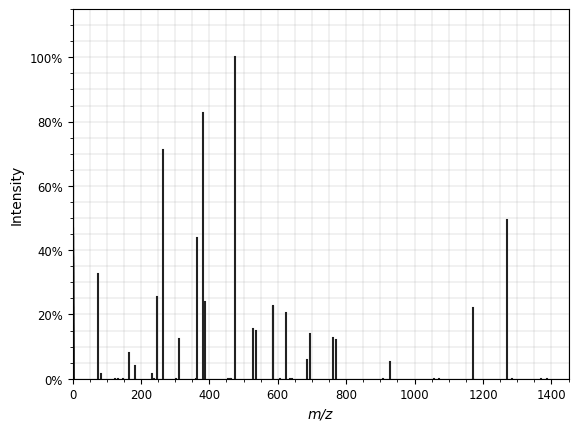

In [22]:
plot_intensity_spectrum(get_peptide_seq(seqs[7]), charges[7], noise)

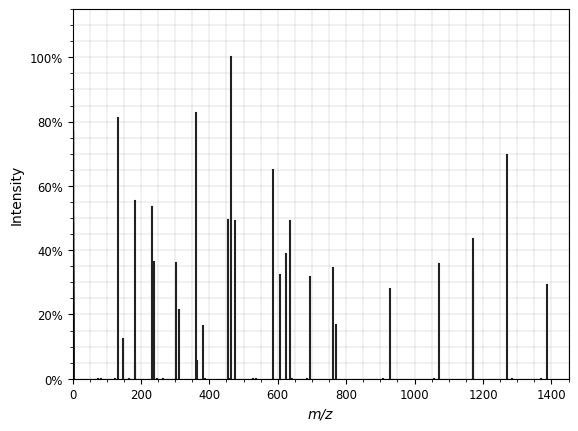

In [127]:
plot_intensity_spectrum(get_peptide_seq(seqs[index]), charges[index], noise[0])

In [ ]:
get_peptide_seq(seqs[0])

'YVVVYFREIDTK'

In [ ]:
charges[0]

np.int64(2)

In [ ]:
seqs[0]

array([20, 18, 18, 18, 20,  5, 15,  4,  8,  3, 17,  9,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [5]:
index = 7

In [8]:
get_peptide_seq(seqs[index])

'YVVVYFREIDTK'

In [9]:
 charges[index]

np.int64(2)

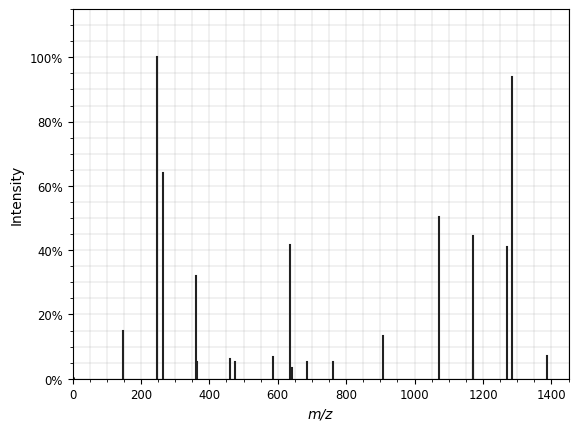

In [6]:
plot_intensity_spectrum(get_peptide_seq(seqs[index]), charges[index], intensities[index])

In [ ]:
seqs[2] - seqs[0]
charges[2] - charges[0]

np.int64(0)

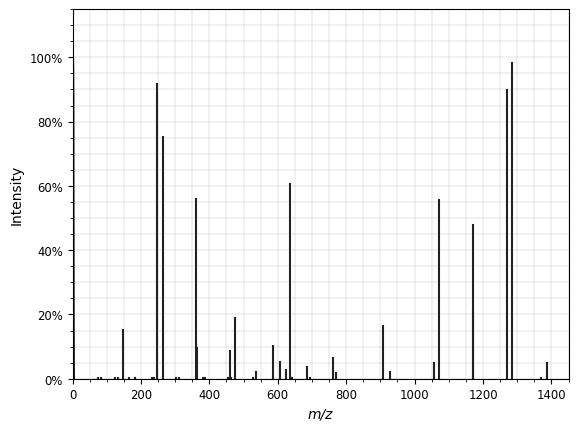

In [ ]:
plot_intensity_spectrum(get_peptide_seq(seqs[index]), charges[index], generated_np[0])